In [1]:
import numpy as np
from matplotlib.cm import get_cmap
import matplotlib.pyplot as plt
import matplotlib as mpl
from mpl_toolkits.axes_grid1.inset_locator import inset_axes

import multiprocessing as mp
from tqdm import tqdm
from joblib import Parallel, delayed
from scipy import stats
import os
from stoch_sim_model import *
from optimize_nets import *
import seaborn as sns

plt.style.use('custom.mplstyle')
%config InlineBackend.figure_format = 'retina'

In [2]:
sample_virs = np.array(np.meshgrid(d_S*np.logspace(np.log10(1/sim_duration/d_S), 2.0, 11), # vary d_I
                                   K_IE*np.logspace(0.0, 2.0, 11), # vary K_IE
                                   b_I*np.logspace(-1, 1, 11) # vary b_I
                                           )).T.reshape(-1,3)

default_reg = act_psis + NM_psis + EM_psis + exp_psis

d="/gscratch/scrubbed/oukogu/infoimmune/sim_output/no_cell_var/"

In [3]:
# run simulations for extreme scenarios
run(batch = [-1], outdir=d, inf_sample = sample_virs, comment="single-reg-vary-virs", vir_model = "indep_harm", default_reg = default_reg, num_cpu = 40)

Running 1331 simulations in batch #-1


/opt/minimamba/envs/maximmune/lib/python3.11/site-packages/numpy/core/fromnumeric.py:3464: RuntimeWarning: Mean of empty slice.
  return _methods._mean(a, axis=axis, dtype=dtype,
/opt/minimamba/envs/maximmune/lib/python3.11/site-packages/numpy/core/fromnumeric.py:3464: RuntimeWarning: Mean of empty slice.
  return _methods._mean(a, axis=axis, dtype=dtype,
/opt/minimamba/envs/maximmune/lib/python3.11/site-packages/numpy/core/fromnumeric.py:3464: RuntimeWarning: Mean of empty slice.
  return _methods._mean(a, axis=axis, dtype=dtype,
/opt/minimamba/envs/maximmune/lib/python3.11/site-packages/numpy/core/fromnumeric.py:3464: RuntimeWarning: Mean of empty slice.
  return _methods._mean(a, axis=axis, dtype=dtype,
/opt/minimamba/envs/maximmune/lib/python3.11/site-packages/numpy/core/_methods.py:192: RuntimeWarning: invalid value encountered in scalar divide
  ret = ret.dtype.type(ret / rcount)
/opt/minimamba/envs/maximmune/lib/python3.11/site-packages/numpy/core/_methods.py:192: RuntimeWarning

Saved sim_batch_-1-1-prim-single-reg-vary-virs.pkl


In [4]:
d_file = '/gscratch/scrubbed/oukogu/infoimmune/sim_output/no_cell_var/raw/sim_batch_-1-1-prim-single-reg-vary-virs.pkl'
with open(d_file, 'rb') as f:   
    data_dict = pickle.load(f)

n = len(sample_virs)
parameters = data_dict["parameters"]
sim_summary = data_dict["summary_stats"]
dyn = data_dict["cell_time_series"]
p_diff = data_dict["prim_diff_bias"]

In [5]:
var_names = np.concatenate((param_names_for_df, stat_names_for_df))
data_df = pd.DataFrame(np.hstack((parameters, sim_summary)), columns = [i for i in var_names]).dropna(thresh=1)
data_df['T_min_pI_corrected'] = 20*(data_df['T_min_pI'] == 0) + data_df['T_min_pI']

with pd.option_context('display.max_columns', None):
    display(data_df)

,S_0,I_0,b_I,d_S,d_I,d_IE,d_IH,K_IE,K_IH,A_init,b_Ain,b_H,d_H,K_EI,K_EH,N_0,max_Na,b_myc,d_myc,myc_thresh,t_act,t_bind,t_Na_div,t_E_div,t_M_div,t_E_die,t_E_cyt,psi_Nact_I,psi_Nact_H,psi_Nact_IH,F0_Nact,psi_NM_I,psi_NM_H,psi_NM_IH,F0_NM,psi_EM_I,psi_EM_H,psi_EM_IH,F0_EM,psi_Ediv_I,psi_Ediv_H,psi_Ediv_IH,F0_Ediv,p_load,s_load,T_max_pI,T_min_pI,harm_pI,harm_sI,harm_pS,harm_sS,max_pE,max_sE,T_pE,T_sE,inf_pM,inf_sM,init_M,int_pE,int_sE,int_pH,int_sH,min_pS,min_sS,T_min_pI_corrected
0,10000000.0,1000.0,1.000000e-08,0.01,0.04,12.0,0.0,10000.000000,5000.0,1000.0,1.0,1.0,2.0,10000.000000,5000.0,0.0,8.0,1592.428682,2.376505,398.107171,1.0,0.75,0.25,0.333333,0.5,2.5,0.666667,2.0,2.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,2.0,2.0,0.0,0.0,5.831870e+03,5.831870e+03,5.0000,0.0,1.583062e+03,1.583062e+03,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.035320e+02,1.035320e+02,9.999431e+06,9.999431e+06,20.0
1,10000000.0,1000.0,1.000000e-08,0.01,0.04,12.0,0.0,15848.931925,5000.0,1000.0,1.0,1.0,2.0,15848.931925,5000.0,0.0,8.0,1592.428682,2.376505,398.107171,1.0,0.75,0.25,0.333333,0.5,2.5,0.666667,2.0,2.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,2.0,2.0,0.0,0.0,5.831870e+03,5.831870e+03,5.0000,0.0,1.583062e+03,1.583062e+03,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.035320e+02,1.035320e+02,9.999431e+06,9.999431e+06,20.0
2,10000000.0,1000.0,1.000000e-08,0.01,0.04,12.0,0.0,25118.864315,5000.0,1000.0,1.0,1.0,2.0,25118.864315,5000.0,0.0,8.0,1592.428682,2.376505,398.107171,1.0,0.75,0.25,0.333333,0.5,2.5,0.666667,2.0,2.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,2.0,2.0,0.0,0.0,5.831870e+03,5.831870e+03,5.0000,0.0,1.583062e+03,1.583062e+03,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.035320e+02,1.035320e+02,9.999431e+06,9.999431e+06,20.0
3,10000000.0,1000.0,1.000000e-08,0.01,0.04,12.0,0.0,39810.717055,5000.0,1000.0,1.0,1.0,2.0,39810.717055,5000.0,0.0,8.0,1592.428682,2.376505,398.107171,1.0,0.75,0.25,0.333333,0.5,2.5,0.666667,2.0,2.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,2.0,2.0,0.0,0.0,5.831870e+03,5.831870e+03,5.0000,0.0,1.583062e+03,1.583062e+03,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.035320e+02,1.035320e+02,9.999431e+06,9.999431e+06,20.0
4,10000000.0,1000.0,1.000000e-08,0.01,0.04,12.0,0.0,63095.734448,5000.0,1000.0,1.0,1.0,2.0,63095.734448,5000.0,0.0,8.0,1592.428682,2.376505,398.107171,1.0,0.75,0.25,0.333333,0.5,2.5,0.666667,2.0,2.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,2.0,2.0,0.0,0.0,5.831870e+03,5.831870e+03,5.0000,0.0,1.583062e+03,1.583062e+03,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.035320e+02,1.035320e+02,9.999431e+06,9.999431e+06,20.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1326,10000000.0,1000.0,1.000000e-06,0.01,1.00,12.0,0.0,158489.319246,5000.0,1000.0,1.0,1.0,2.0,158489.319246,5000.0,0.0,8.0,1592.428682,2.376505,398.107171,1.0,0.75,0.25,0.333333,0.5,2.5,0.666667,2.0,2.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,2.0,2.0,0.0,0.0,1.001164e+07,1.001164e+07,1.2928,0.0,1.025291e+07,1.025291e+07,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,4.897732e+06,4.897732e+06,3.442392e+04,3.442392e+04,20.0
1327,10000000.0,1000.0,1.000000e-06,0.01,1.00,12.0,0.0,251188.643151,5000.0,1000.0,1.0,1.0,2.0,251188.643151,5000.0,0.0,8.0,1592.428682,2.376505,398.107171,1.0,0.75,0.25,0.333333,0.5,2.5,0.666667,2.0,2.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,2.0,2.0,0.0,0.0,1.001164e+07,1.001164e+07,1.2928,0.0,1.025291e+07,1.025291e+07,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,4.897732e+06,4.897732e+06,3.442392e+04,3.442392e+04,20.0
1328,10000000.0,1000.0,1.000000e-06,0.01,1.00,12.0,0.0,398107.170553,5000.0,1000.0,1.0,1.0,2.0,398107.170553,5000.0,0.0,8.0,1592.428682,2.376505,398.107171,1.0,0.75,0.25,0.333333,0.5,2.5,0.666667,2.0,2.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,2.0,2.0,0.0,0.0,1.001164e+07,1.001164e+07,1.2928,0.0,1.025291e+07,1

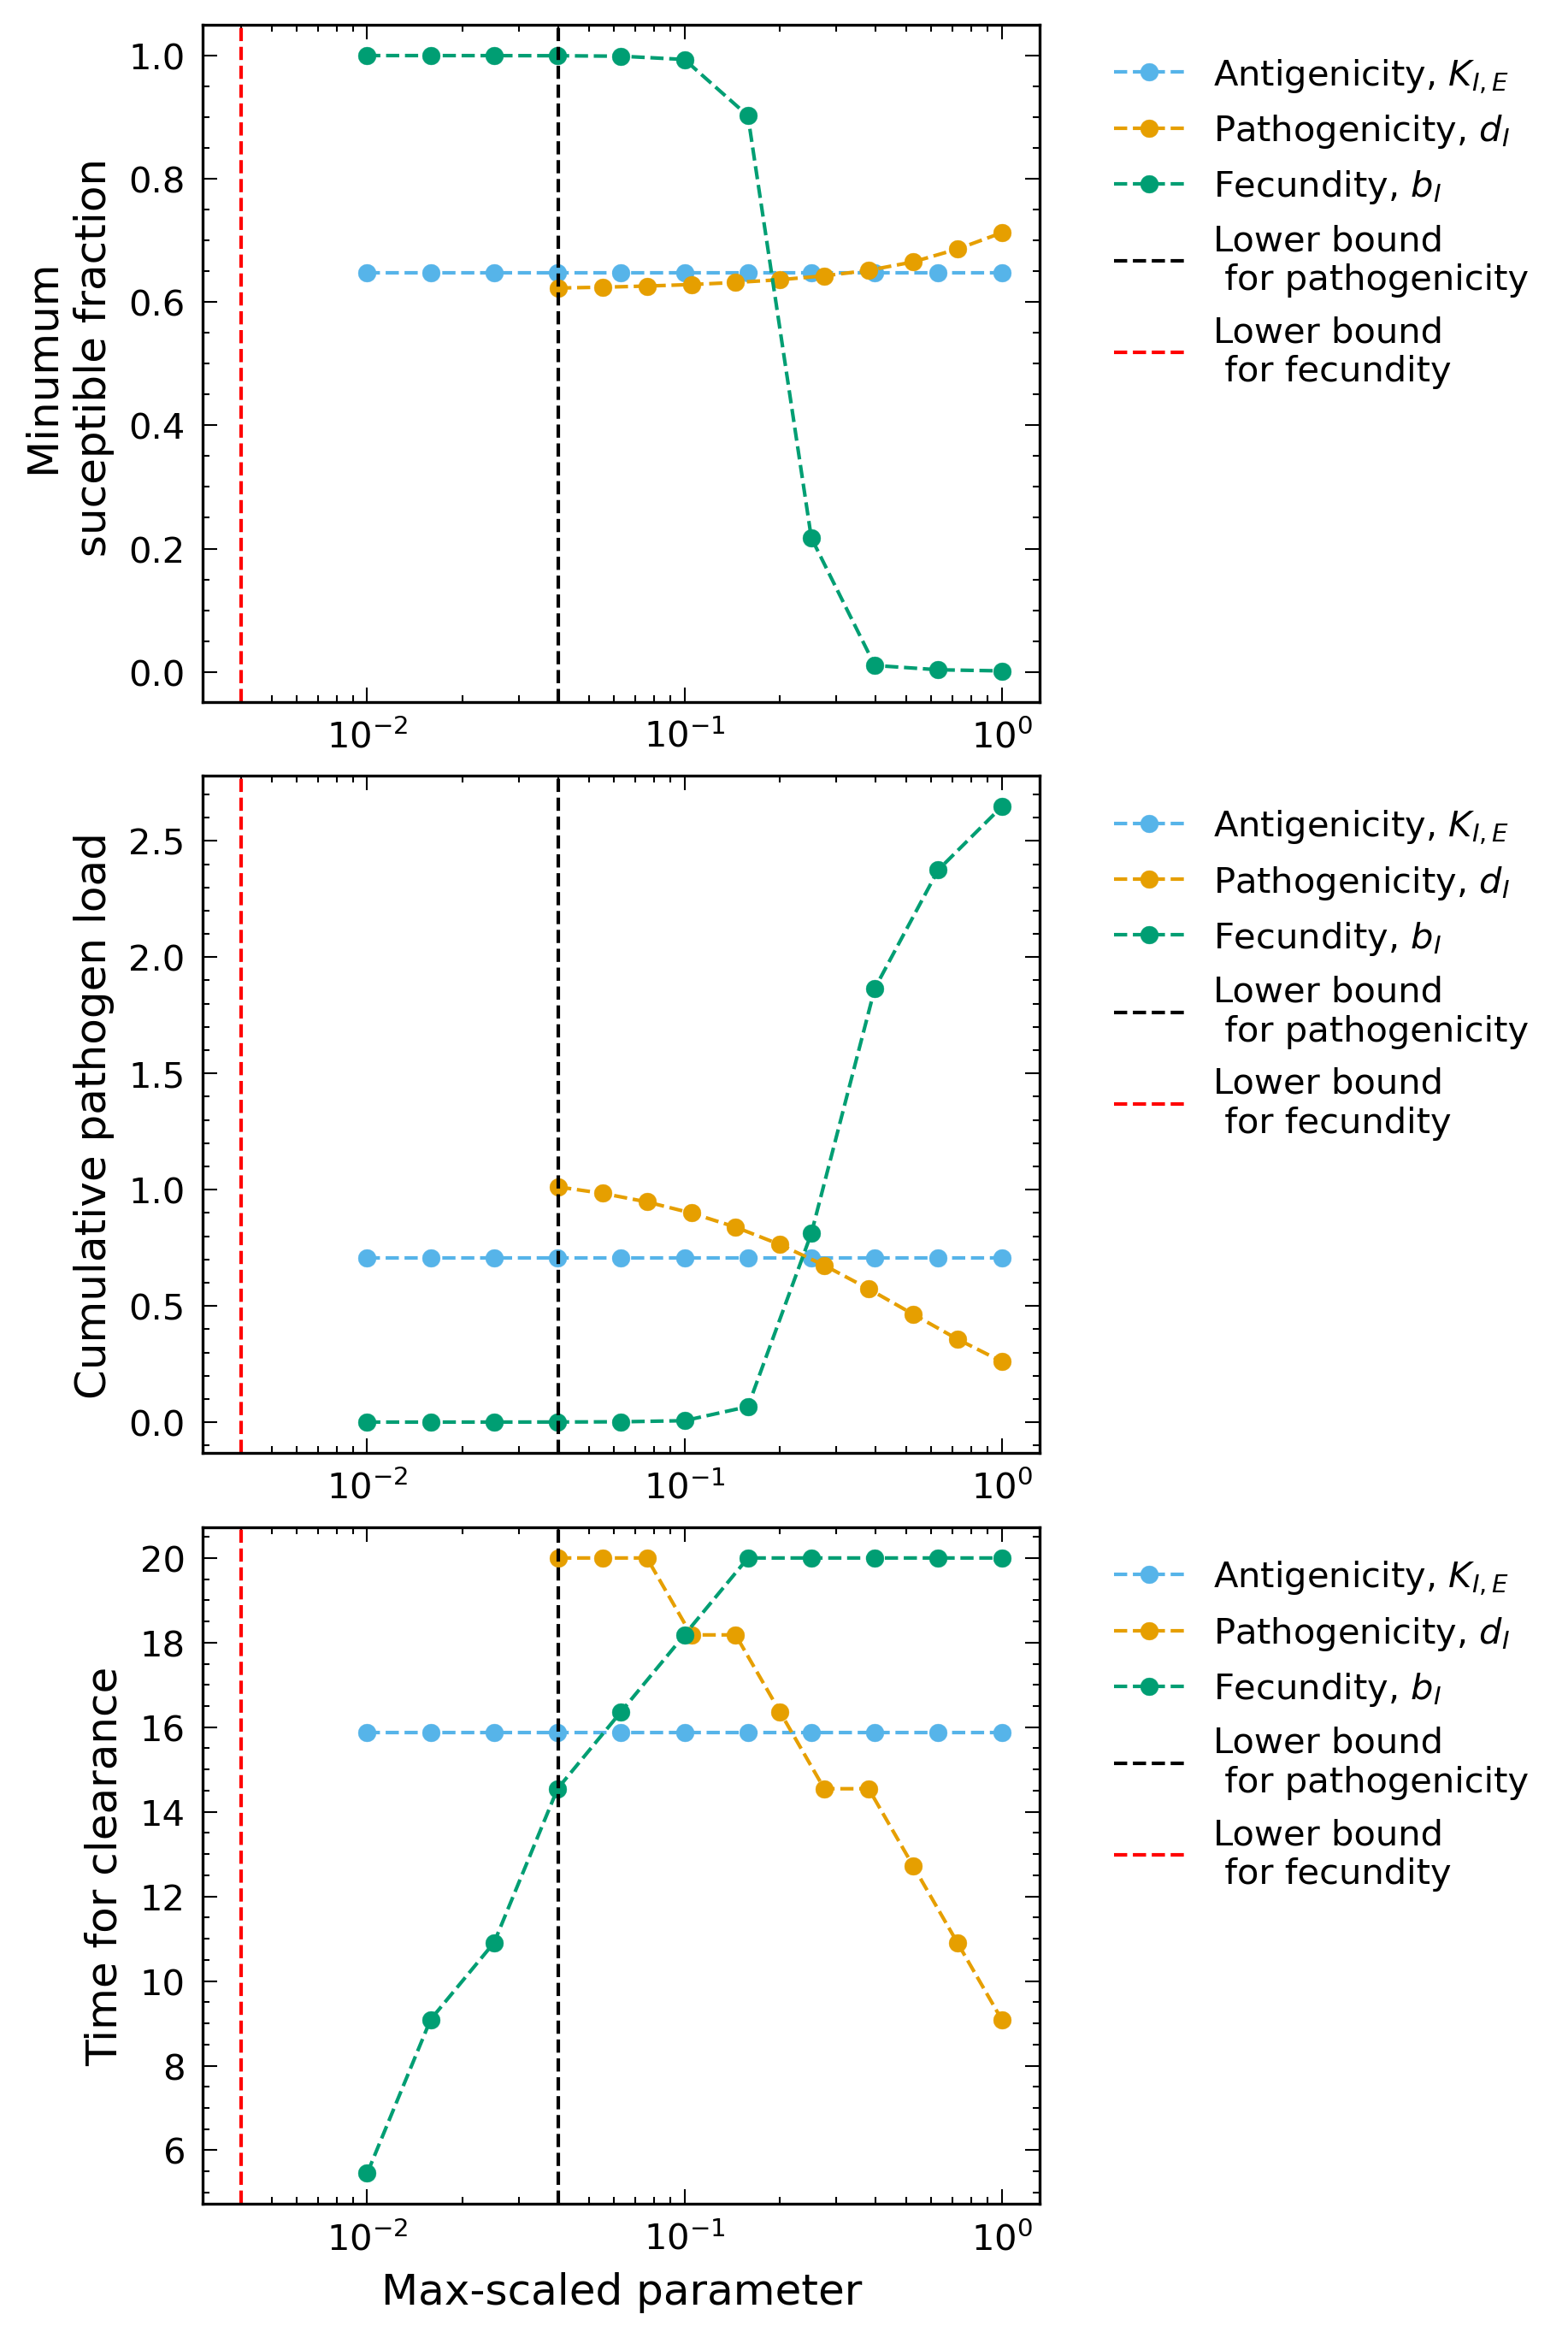

In [6]:
# Plot simulated immune dynamics
fig, (ax1, ax2, ax3) = plt.subplots(3, dpi = 150, constrained_layout=True, sharex = False, figsize=(6,9))


ax1.plot(data_df.groupby(['K_IE'], as_index=False).mean()['K_IE']/np.max(data_df['K_IE']), data_df.groupby(['K_IE'], as_index=False).mean()['min_pS']/S_0, 'o--', label = 'Antigenicity, $K_{I,E}$')
ax1.plot(data_df.groupby(['d_I'], as_index=False).mean()['d_I']/np.max(data_df['d_I']), data_df.groupby(['d_I'], as_index=False).mean()['min_pS']/S_0, 'o--', label = 'Pathogenicity, $d_{I}$')
ax1.plot(data_df.groupby(['b_I'], as_index=False).mean()['b_I']/np.max(data_df['b_I']), data_df.groupby(['b_I'], as_index=False).mean()['min_pS']/S_0, 'o--', label = 'Fecundity, $b_{I}$')
ax1.axvline(x = 1/sim_duration/np.max(data_df['d_I']), color = 'k', linestyle = '--', label = "Lower bound \n for pathogenicity")
ax1.axvline(x = 1/(sim_duration*S_0)*(1/np.max(data_df['b_I'])), color = 'r', linestyle = '--', label = "Lower bound \n for fecundity")
ax1.semilogx()
ax1.legend(bbox_to_anchor=(1.05, 1.0), loc='upper left')
ax1.set(ylabel = 'Minumum \n suceptible fraction')

ax2.plot(data_df.groupby(['K_IE'], as_index=False).mean()['K_IE']/np.max(data_df['K_IE']), data_df.groupby(['K_IE'], as_index=False).mean()['p_load']/S_0, 'o--', label = 'Antigenicity, $K_{I,E}$')
ax2.plot(data_df.groupby(['d_I'], as_index=False).mean()['d_I']/np.max(data_df['d_I']), data_df.groupby(['d_I'], as_index=False).mean()['p_load']/S_0, 'o--', label = 'Pathogenicity, $d_{I}$')
ax2.plot(data_df.groupby(['b_I'], as_index=False).mean()['b_I']/np.max(data_df['b_I']), data_df.groupby(['b_I'], as_index=False).mean()['p_load']/S_0, 'o--', label = 'Fecundity, $b_{I}$')
ax2.axvline(x = 1/sim_duration/np.max(data_df['d_I']), color = 'k', linestyle = '--', label = "Lower bound \n for pathogenicity")
ax2.axvline(x = 1/(sim_duration*S_0)*(1/np.max(data_df['b_I'])), color = 'r', linestyle = '--', label = "Lower bound \n for fecundity")
ax2.semilogx()
ax2.set(ylabel = 'Cumulative pathogen load')
ax2.legend(bbox_to_anchor=(1.05, 1.0), loc='upper left')

ax3.plot(data_df.groupby(['K_IE'], as_index=False).mean()['K_IE']/np.max(data_df['K_IE']), data_df.groupby(['K_IE'], as_index=False).mean()['T_min_pI_corrected'], 'o--', label = 'Antigenicity, $K_{I,E}$')
ax3.plot(data_df.groupby(['d_I'], as_index=False).mean()['d_I']/np.max(data_df['d_I']), data_df.groupby(['d_I'], as_index=False).mean()['T_min_pI_corrected'], 'o--', label = 'Pathogenicity, $d_{I}$')
ax3.plot(data_df.groupby(['b_I'], as_index=False).mean()['b_I']/np.max(data_df['b_I']), data_df.groupby(['b_I'], as_index=False).mean()['T_min_pI_corrected'], 'o--', label = 'Fecundity, $b_{I}$')
ax3.axvline(x = 1/sim_duration/np.max(data_df['d_I']), color = 'k', linestyle = '--', label = "Lower bound \n for pathogenicity")
ax3.axvline(x = 1/(sim_duration*S_0)*(1/np.max(data_df['b_I'])), color = 'r', linestyle = '--', label = "Lower bound \n for fecundity")
ax3.set(ylabel = 'Time for clearance', xlabel = 'Max-scaled parameter')
ax3.semilogx()
ax3.legend(bbox_to_anchor=(1.05, 1.0), loc='upper left')


plt.savefig('_figs/vir_parameter_lineplots', dpi=300, bbox_inches='tight')

RuntimeError: Error in qhull Delaunay triangulation calculation: singular input data (exitcode=2); use python verbose option (-v) to see original qhull error.

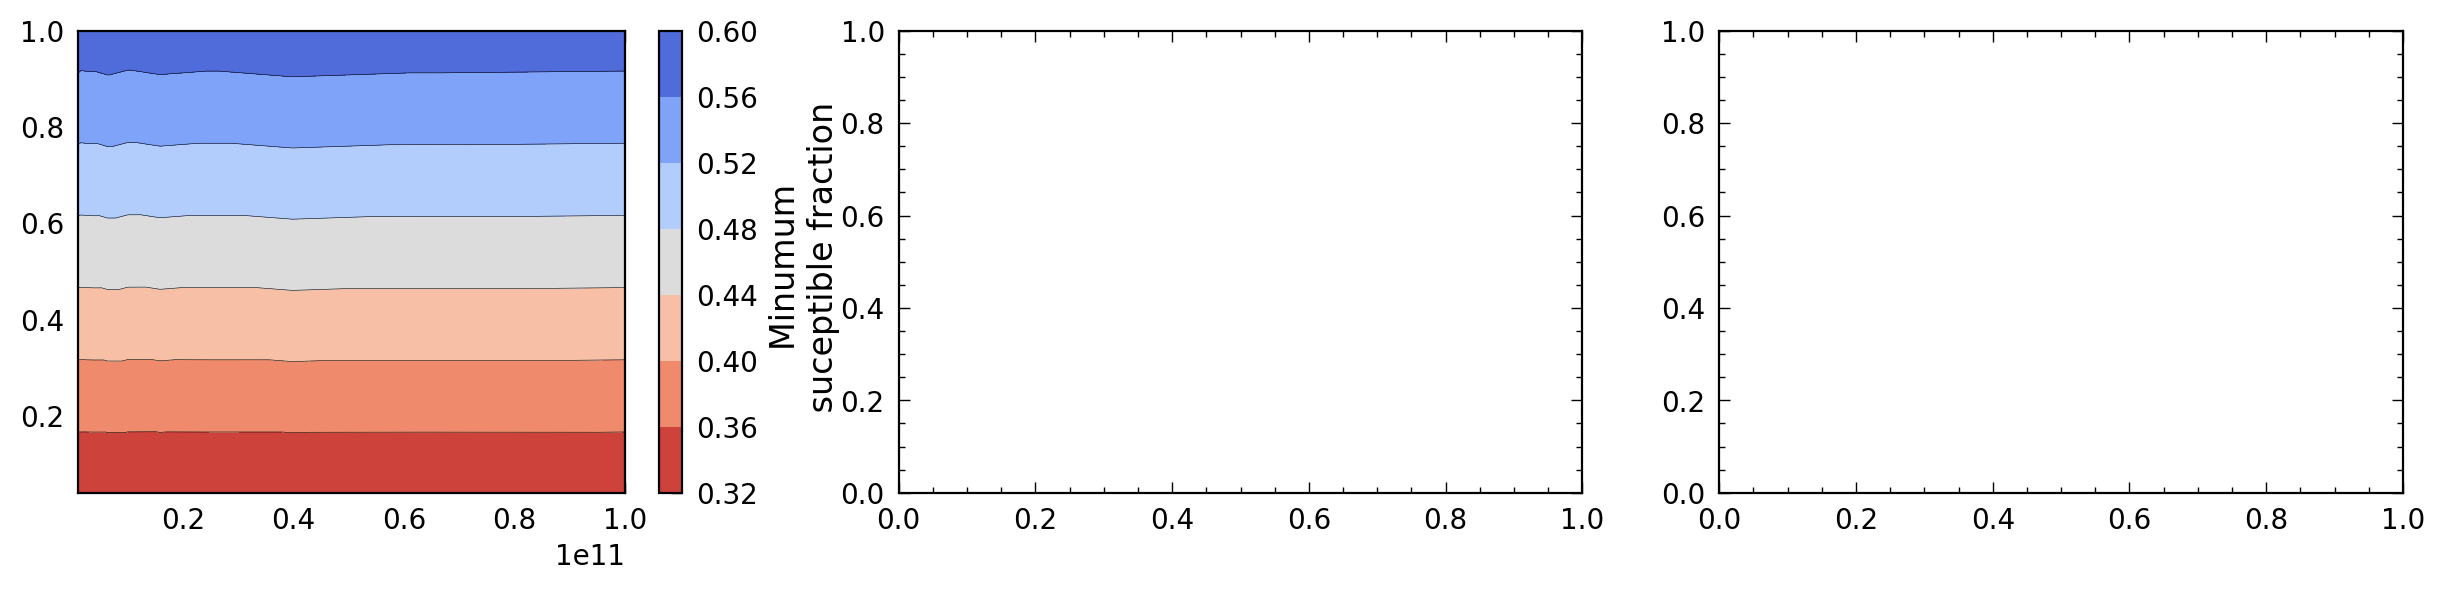

In [15]:
fig, axs = plt.subplots(1, 3, figsize=(15, 3), sharex=False, sharey=False)

axs[0].tricontour(data_df.groupby(['K_IE','d_I'], as_index=False).mean()['K_IE'], 
                  data_df.groupby(['K_IE','d_I'], as_index=False).mean()['d_I'], 
                  data_df.groupby(['K_IE','d_I'], as_index=False).mean()['min_pS']/S_0, linewidths=0.2, colors='k')
im0 = axs[0].tricontourf(data_df.groupby(['K_IE','d_I'], as_index=False).mean()['K_IE'], 
                        data_df.groupby(['K_IE','d_I'], as_index=False).mean()['d_I'], 
                        data_df.groupby(['K_IE','d_I'], as_index=False).mean()['min_pS']/S_0, cmap="coolwarm_r")

cb = fig.colorbar(im0, ax=axs[0], orientation='vertical')
cb.set_label("Minumum \n suceptible fraction", fontsize = 12)

axs[1].tricontour(data_df.groupby(['K_IE','b_I'], as_index=False).mean()['K_IE'], 
                  data_df.groupby(['K_IE','b_I'], as_index=False).mean()['b_I'], 
                  data_df.groupby(['K_IE','b_I'], as_index=False).mean()['min_pS']/S_0, linewidths=0.2, colors='k')
im1 = axs[1].tricontourf(data_df.groupby(['K_IE','b_I'], as_index=False).mean()['K_IE'], 
                        data_df.groupby(['K_IE','b_I'], as_index=False).mean()['b_I'], 
                        data_df.groupby(['K_IE','b_I'], as_index=False).mean()['min_pS']/S_0, cmap="coolwarm_r")

cb = fig.colorbar(im1, ax=axs[1], orientation='vertical')
cb.set_label("Minumum \n suceptible fraction", fontsize = 12)

axs[2].tricontour(data_df.groupby(['b_I','d_I'], as_index=False).mean()['b_I'], 
                  data_df.groupby(['b_I','d_I'], as_index=False).mean()['d_I'], 
                  data_df.groupby(['b_I','d_I'], as_index=False).mean()['min_pS']/S_0, linewidths=0.2, colors='k')
im2 = axs[2].tricontourf(data_df.groupby(['b_I','d_I'], as_index=False).mean()['b_I'], 
                        data_df.groupby(['b_I','d_I'], as_index=False).mean()['d_I'], 
                        data_df.groupby(['b_I','d_I'], as_index=False).mean()['min_pS']/S_0, cmap="coolwarm_r")

cb = fig.colorbar(im2, ax=axs[2], orientation='vertical')
cb.set_label("Minumum \n suceptible fraction", fontsize = 12)

axs[0].set_title(r"Antigenicity $K_{I,E}$ vs. Pathogenicity $d_I$", fontsize = 12)
axs[1].set_title(r"Antigenicity $K_{I,E}$ vs. Fecundity $b_I$", fontsize = 12)
axs[2].set_title(r"Fecundity $b_I$ vs. Pathogenicity $d_I$", fontsize = 12)

axs[0].set_ylabel("Pathogenicity, $d_I$", fontsize = 10)
axs[0].set_xlabel("Antigenicity, $K_{I,E}$", fontsize = 10)
axs[1].set_ylabel("Fecundity, $b_I$", fontsize = 10)
axs[1].set_xlabel("Antigenicity, $K_{I,E}$", fontsize = 10)
axs[2].set_ylabel("Pathogenicity, $d_I$", fontsize = 10)
axs[2].set_xlabel("Fecundity, $b_I$", fontsize = 10)

for j, ax in enumerate(axs.flat):
    ax.semilogy()
    ax.semilogx()

fig.subplots_adjust(wspace=.5, hspace=.5)
    
plt.savefig('_figs/vir_parameter_w_Smin_contour', dpi=300, bbox_inches='tight')

RuntimeError: Error in qhull Delaunay triangulation calculation: singular input data (exitcode=2); use python verbose option (-v) to see original qhull error.

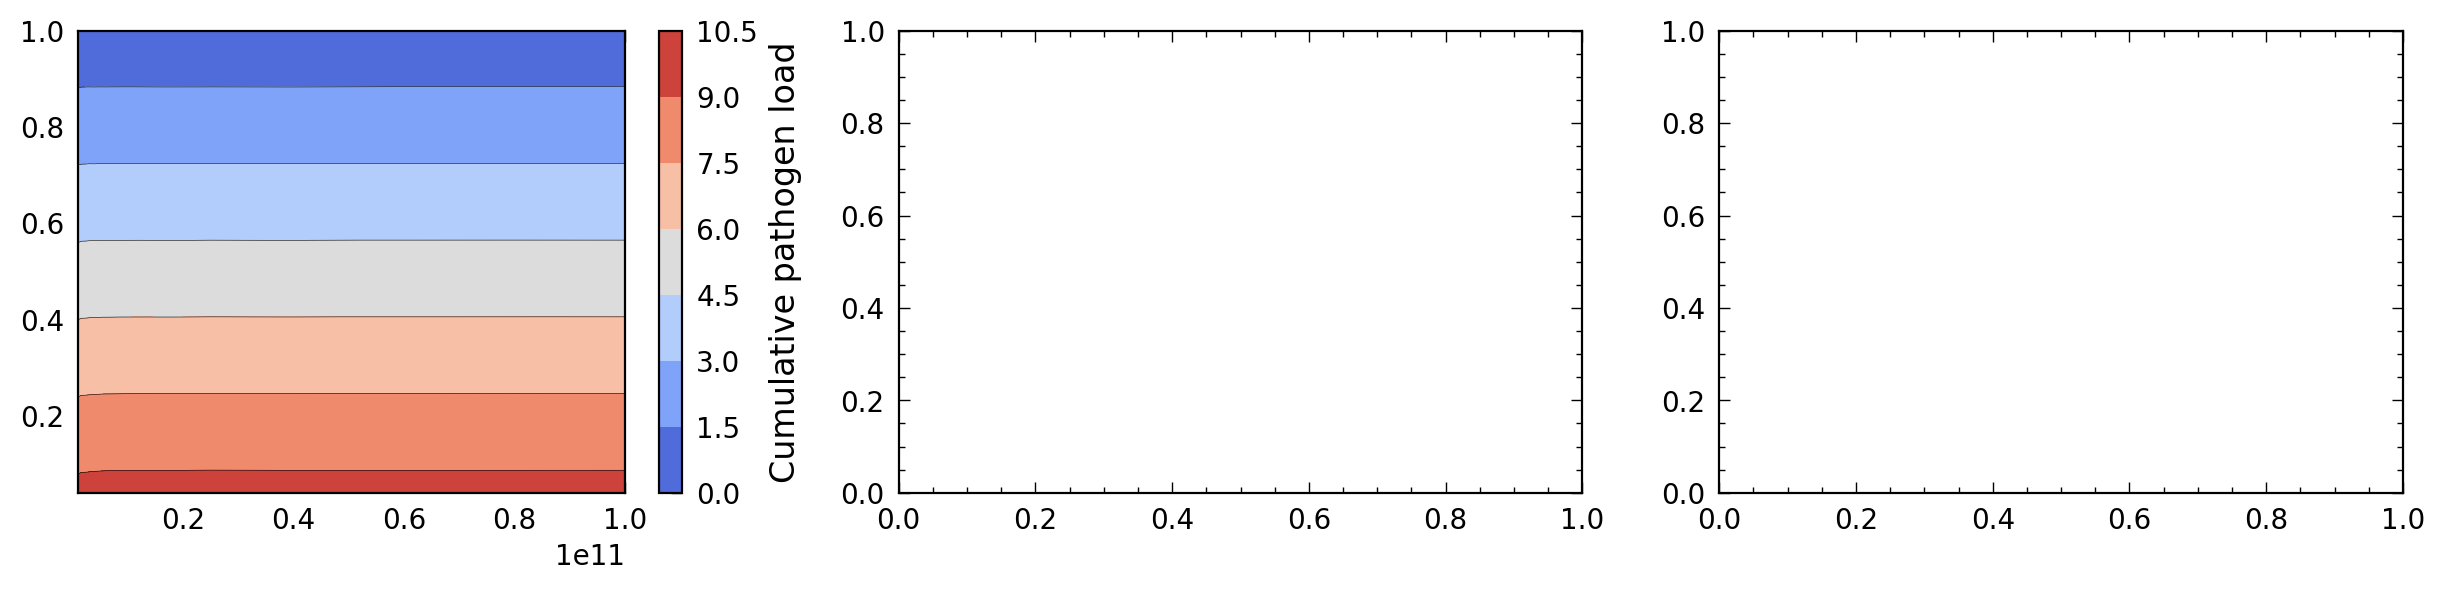

In [16]:
fig, axs = plt.subplots(1, 3, figsize=(15, 3), sharex=False, sharey=False)

axs[0].tricontour(data_df.groupby(['K_IE','d_I'], as_index=False).mean()['K_IE'], 
                  data_df.groupby(['K_IE','d_I'], as_index=False).mean()['d_I'], 
                  data_df.groupby(['K_IE','d_I'], as_index=False).mean()['p_load']/S_0, linewidths=0.2, colors='k')
im0 = axs[0].tricontourf(data_df.groupby(['K_IE','d_I'], as_index=False).mean()['K_IE'], 
                        data_df.groupby(['K_IE','d_I'], as_index=False).mean()['d_I'], 
                        data_df.groupby(['K_IE','d_I'], as_index=False).mean()['p_load']/S_0, cmap="coolwarm")

cb = fig.colorbar(im0, ax=axs[0], orientation='vertical')
cb.set_label("Cumulative pathogen load", fontsize = 12)

axs[1].tricontour(data_df.groupby(['K_IE','b_I'], as_index=False).mean()['K_IE'], 
                  data_df.groupby(['K_IE','b_I'], as_index=False).mean()['b_I'], 
                  data_df.groupby(['K_IE','b_I'], as_index=False).mean()['p_load']/S_0, linewidths=0.2, colors='k')
im1 = axs[1].tricontourf(data_df.groupby(['K_IE','b_I'], as_index=False).mean()['K_IE'], 
                        data_df.groupby(['K_IE','b_I'], as_index=False).mean()['b_I'], 
                        data_df.groupby(['K_IE','b_I'], as_index=False).mean()['p_load']/S_0, cmap="coolwarm")

cb = fig.colorbar(im1, ax=axs[1], orientation='vertical')
cb.set_label("Cumulative pathogen load", fontsize = 12)

axs[2].tricontour(data_df.groupby(['b_I','d_I'], as_index=False).mean()['b_I'], 
                  data_df.groupby(['b_I','d_I'], as_index=False).mean()['d_I'], 
                  data_df.groupby(['b_I','d_I'], as_index=False).mean()['p_load']/S_0, linewidths=0.2, colors='k')
im2 = axs[2].tricontourf(data_df.groupby(['b_I','d_I'], as_index=False).mean()['b_I'], 
                        data_df.groupby(['b_I','d_I'], as_index=False).mean()['d_I'], 
                        data_df.groupby(['b_I','d_I'], as_index=False).mean()['p_load']/S_0, cmap="coolwarm")

cb = fig.colorbar(im2, ax=axs[2], orientation='vertical')
cb.set_label("Cumulative pathogen load", fontsize = 12)

axs[0].set_title(r"Antigenicity $K_{I,E}$ vs. Pathogenicity $d_I$", fontsize = 12)
axs[1].set_title(r"Antigenicity $K_{I,E}$ vs. Fecundity $b_I$", fontsize = 12)
axs[2].set_title(r"Fecundity $b_I$ vs. Pathogenicity $d_I$", fontsize = 12)

axs[0].set_ylabel("Pathogenicity, $d_I$", fontsize = 10)
axs[0].set_xlabel("Antigenicity, $K_{I,E}$", fontsize = 10)
axs[1].set_ylabel("Fecundity, $b_I$", fontsize = 10)
axs[1].set_xlabel("Antigenicity, $K_{I,E}$", fontsize = 10)
axs[2].set_ylabel("Pathogenicity, $d_I$", fontsize = 10)
axs[2].set_xlabel("Fecundity, $b_I$", fontsize = 10)

for j, ax in enumerate(axs.flat):
    ax.semilogy()
    ax.semilogx()

fig.subplots_adjust(wspace=.5, hspace=.5)
    
plt.savefig('_figs/vir_parameter_w_pload_contour', dpi=300, bbox_inches='tight')

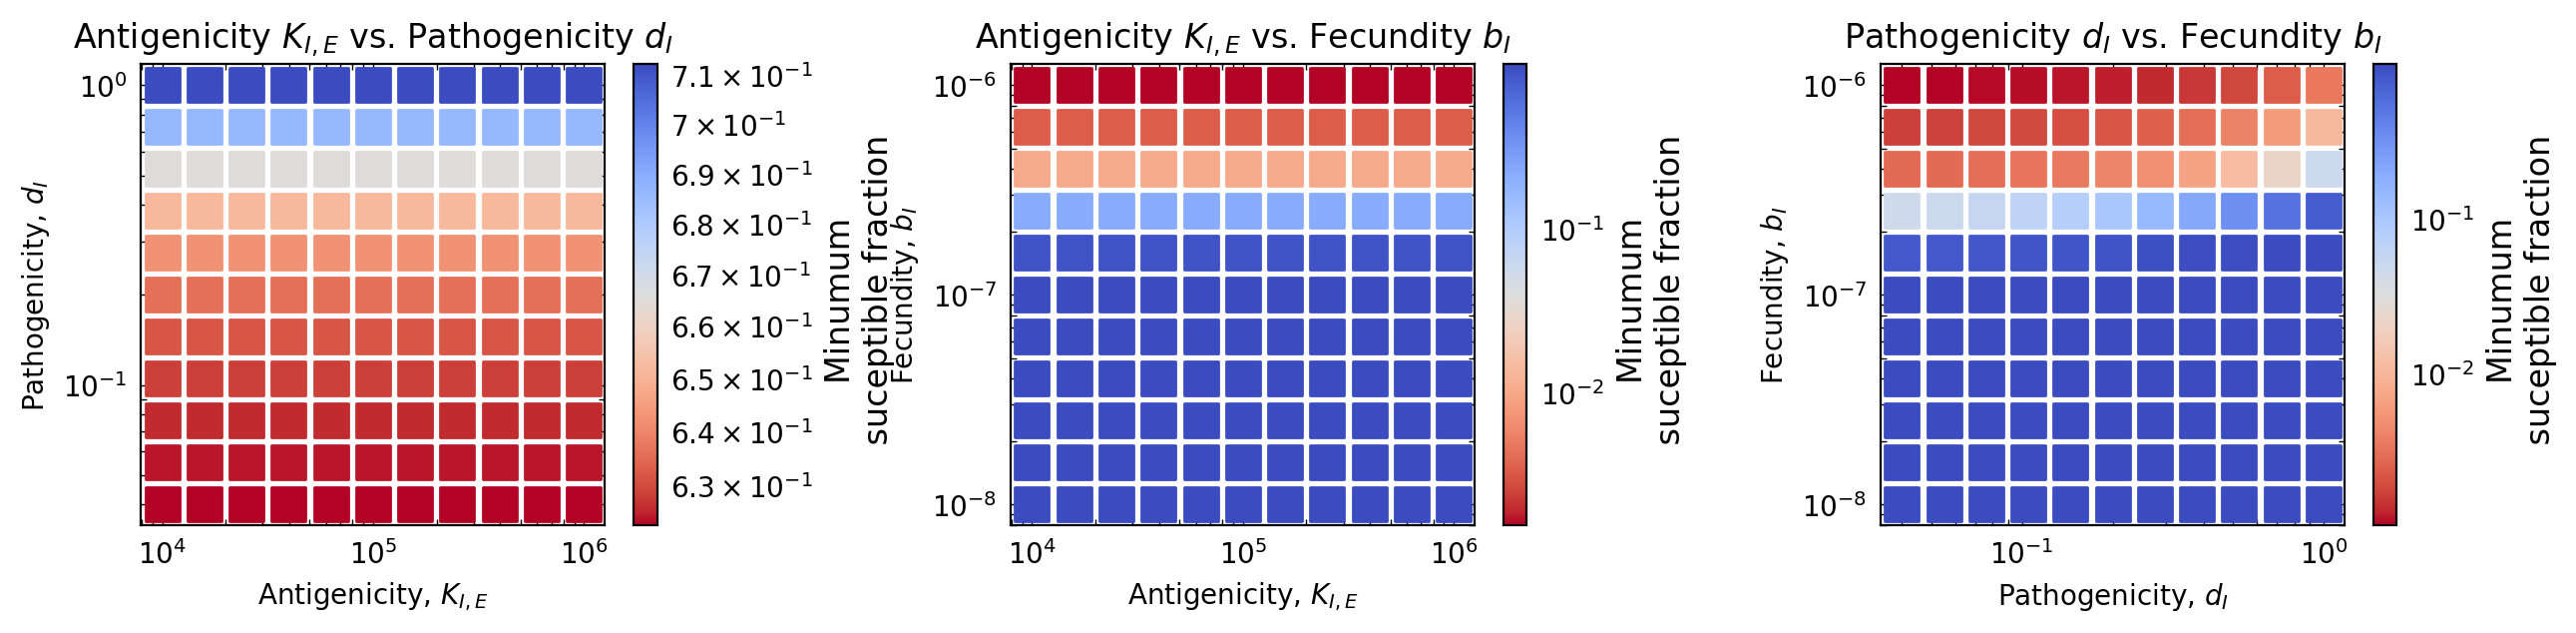

In [7]:
fig, axs = plt.subplots(1, 3, figsize=(15, 3), sharex=False, sharey=False)

im0 = axs[0].scatter(data_df.groupby(['K_IE','d_I'], as_index=False).mean()['K_IE'], data_df.groupby(['K_IE','d_I'], as_index=False).mean()['d_I'], marker = 's', s = 150,
                    c = data_df.groupby(['K_IE','d_I'], as_index=False).mean()['min_pS']/S_0, cmap='coolwarm_r', norm=mpl.colors.LogNorm())
cb = fig.colorbar(im0, ax=axs[0], orientation='vertical')
cb.set_label("Minumum \n suceptible fraction", fontsize = 12)

im1 = axs[1].scatter(data_df.groupby(['K_IE','b_I'], as_index=False).mean()['K_IE'], data_df.groupby(['K_IE','b_I'], as_index=False).mean()['b_I'], marker = 's', s = 150,
               c = data_df.groupby(['K_IE','b_I'], as_index=False).mean()['min_pS']/S_0, cmap='coolwarm_r', norm=mpl.colors.LogNorm())
cb = fig.colorbar(im1, ax=axs[1], orientation='vertical')
cb.set_label("Minumum \n suceptible fraction", fontsize = 12)

im2 = axs[2].scatter(data_df.groupby(['b_I','d_I'], as_index=False).mean()['d_I'], data_df.groupby(['b_I','d_I'], as_index=False).mean()['b_I'], marker = 's', s = 150,
               c = data_df.groupby(['b_I','d_I'], as_index=False).mean()['min_pS']/S_0, cmap='coolwarm_r', norm=mpl.colors.LogNorm())
cb = fig.colorbar(im2, ax=axs[2], orientation='vertical')
cb.set_label("Minumum \n suceptible fraction", fontsize = 12)

axs[0].set_title(r"Antigenicity $K_{I,E}$ vs. Pathogenicity $d_I$", fontsize = 12)
axs[1].set_title(r"Antigenicity $K_{I,E}$ vs. Fecundity $b_I$", fontsize = 12)
axs[2].set_title(r"Pathogenicity $d_I$ vs. Fecundity $b_I$", fontsize = 12)

axs[0].set_ylabel("Pathogenicity, $d_I$", fontsize = 10)
axs[0].set_xlabel("Antigenicity, $K_{I,E}$", fontsize = 10)
axs[1].set_ylabel("Fecundity, $b_I$", fontsize = 10)
axs[1].set_xlabel("Antigenicity, $K_{I,E}$", fontsize = 10)
axs[2].set_ylabel("Fecundity, $b_I$", fontsize = 10)
axs[2].set_xlabel("Pathogenicity, $d_I$", fontsize = 10)


for j, ax in enumerate(axs.flat):
    ax.semilogy()
    ax.semilogx()

fig.subplots_adjust(wspace=.5, hspace=.5)
    
plt.savefig('_figs/vir_parameter_w_Smin_heatmaps', dpi=300, bbox_inches='tight')

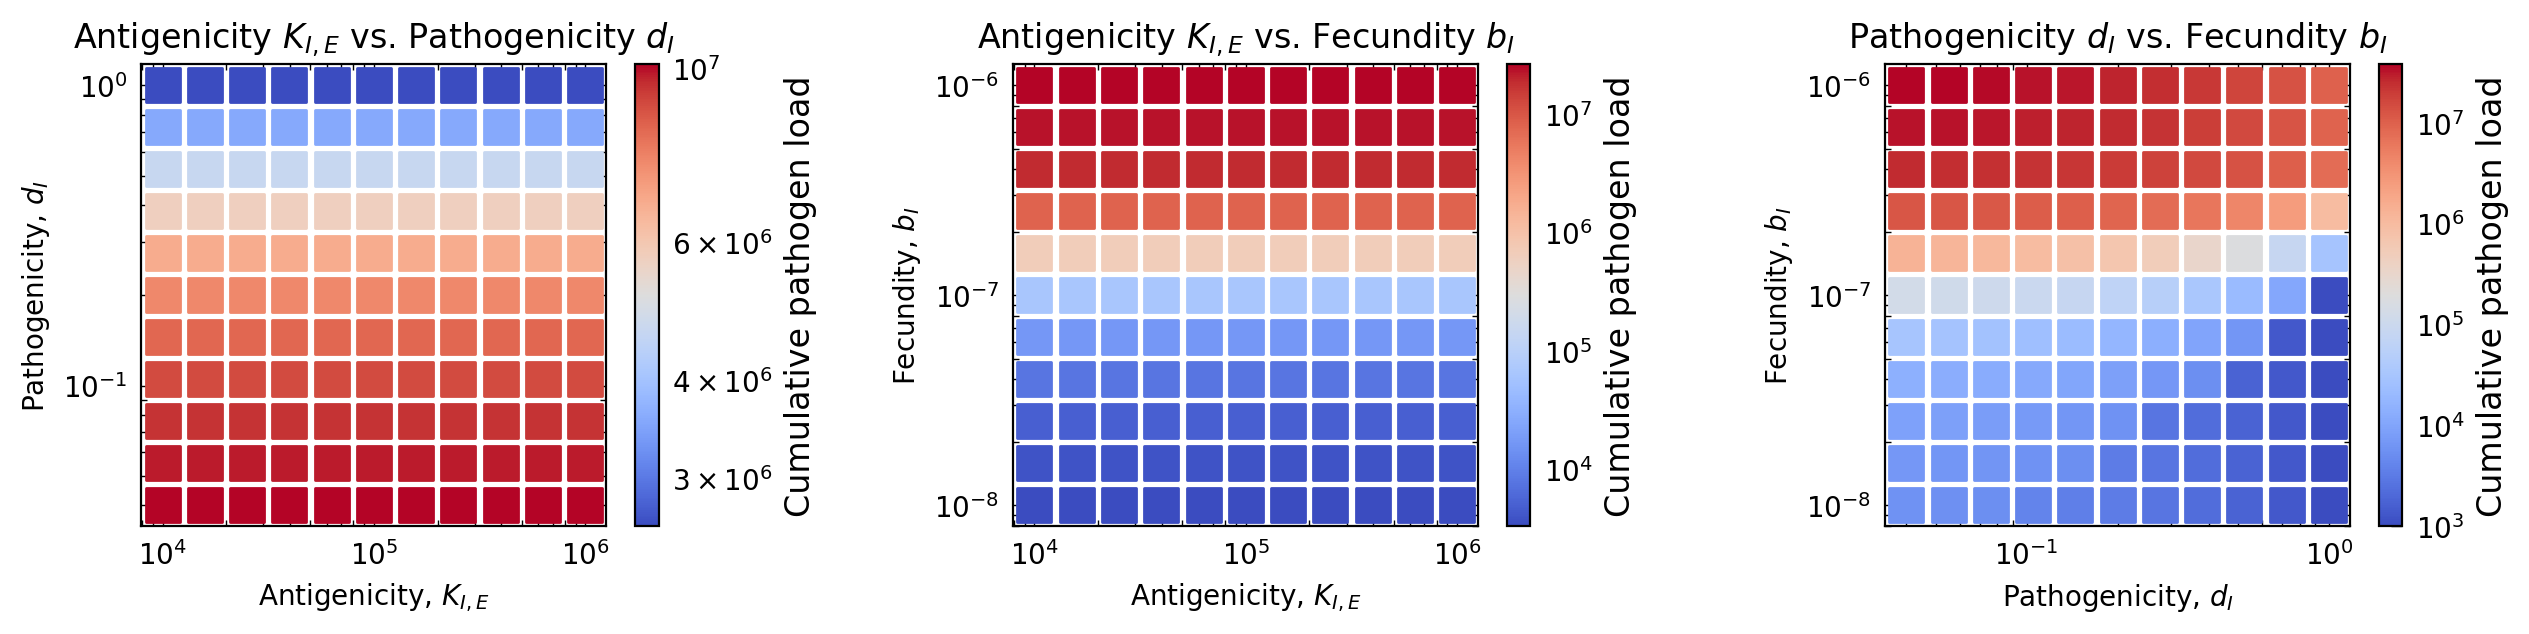

In [8]:
fig, axs = plt.subplots(1, 3, figsize=(15, 3), sharex=False, sharey=False)

im0 = axs[0].scatter(data_df.groupby(['K_IE','d_I'], as_index=False).mean()['K_IE'], data_df.groupby(['K_IE','d_I'], as_index=False).mean()['d_I'], marker = 's', s = 150,
                    c = data_df.groupby(['K_IE','d_I'], as_index=False).mean()['p_load'], cmap='coolwarm', norm=mpl.colors.LogNorm())
cb = fig.colorbar(im0, ax=axs[0], orientation='vertical')
cb.set_label("Cumulative pathogen load", fontsize = 12)

im1 = axs[1].scatter(data_df.groupby(['K_IE','b_I'], as_index=False).mean()['K_IE'], data_df.groupby(['K_IE','b_I'], as_index=False).mean()['b_I'], marker = 's', s = 150,
               c = data_df.groupby(['K_IE','b_I'], as_index=False).mean()['p_load'], cmap='coolwarm', norm=mpl.colors.LogNorm())
cb = fig.colorbar(im1, ax=axs[1], orientation='vertical')
cb.set_label("Cumulative pathogen load", fontsize = 12)

im2 = axs[2].scatter(data_df.groupby(['b_I','d_I'], as_index=False).mean()['d_I'], data_df.groupby(['b_I','d_I'], as_index=False).mean()['b_I'], marker = 's', s = 150,
               c = data_df.groupby(['b_I','d_I'], as_index=False).mean()['p_load'], cmap='coolwarm', norm=mpl.colors.LogNorm())
cb = fig.colorbar(im2, ax=axs[2], orientation='vertical')
cb.set_label("Cumulative pathogen load", fontsize = 12)

axs[0].set_title(r"Antigenicity $K_{I,E}$ vs. Pathogenicity $d_I$", fontsize = 12)
axs[1].set_title(r"Antigenicity $K_{I,E}$ vs. Fecundity $b_I$", fontsize = 12)
axs[2].set_title(r"Pathogenicity $d_I$ vs. Fecundity $b_I$", fontsize = 12)

axs[0].set_ylabel("Pathogenicity, $d_I$", fontsize = 10)
axs[0].set_xlabel("Antigenicity, $K_{I,E}$", fontsize = 10)
axs[1].set_ylabel("Fecundity, $b_I$", fontsize = 10)
axs[1].set_xlabel("Antigenicity, $K_{I,E}$", fontsize = 10)
axs[2].set_ylabel("Fecundity, $b_I$", fontsize = 10)
axs[2].set_xlabel("Pathogenicity, $d_I$", fontsize = 10)

for j, ax in enumerate(axs.flat):
    ax.semilogy()
    ax.semilogx()

fig.subplots_adjust(wspace=.5, hspace=.5)
    
plt.savefig('_figs/vir_parameter_w_pload_heatmaps', dpi=300, bbox_inches='tight')

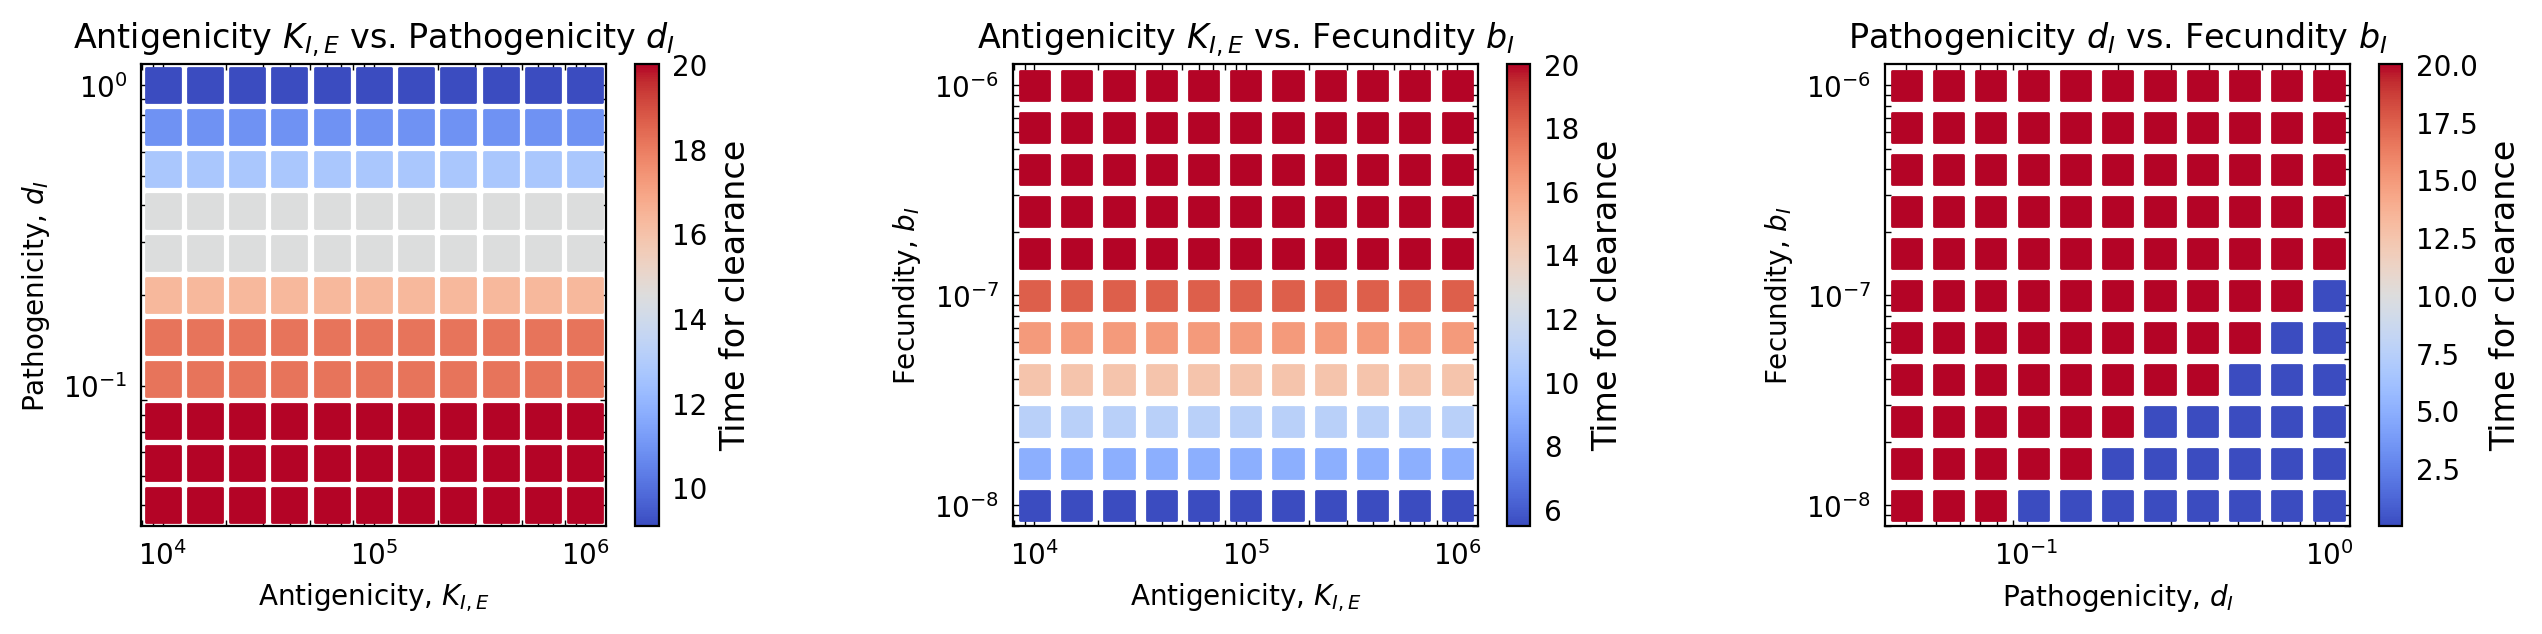

In [9]:
fig, axs = plt.subplots(1, 3, figsize=(15, 3), sharex=False, sharey=False)

im0 = axs[0].scatter(data_df.groupby(['K_IE','d_I'], as_index=False).mean()['K_IE'], data_df.groupby(['K_IE','d_I'], as_index=False).mean()['d_I'], marker = 's', s = 150,
                    c = data_df.groupby(['K_IE','d_I'], as_index=False).mean()['T_min_pI_corrected'], cmap='coolwarm')
cb = fig.colorbar(im0, ax=axs[0], orientation='vertical')
cb.set_label("Time for clearance", fontsize = 12)

im1 = axs[1].scatter(data_df.groupby(['K_IE','b_I'], as_index=False).mean()['K_IE'], data_df.groupby(['K_IE','b_I'], as_index=False).mean()['b_I'], marker = 's', s = 110,
               c = data_df.groupby(['K_IE','b_I'], as_index=False).mean()['T_min_pI_corrected'], cmap='coolwarm')
cb = fig.colorbar(im1, ax=axs[1], orientation='vertical')
cb.set_label("Time for clearance", fontsize = 12)

im2 = axs[2].scatter(data_df.groupby(['b_I','d_I'], as_index=False).mean()['d_I'], data_df.groupby(['b_I','d_I'], as_index=False).mean()['b_I'], marker = 's', s = 110,
               c = data_df.groupby(['b_I','d_I'], as_index=False).mean()['T_min_pI_corrected'], cmap='coolwarm')
cb = fig.colorbar(im2, ax=axs[2], orientation='vertical')
cb.set_label("Time for clearance", fontsize = 12)

axs[0].set_title(r"Antigenicity $K_{I,E}$ vs. Pathogenicity $d_I$", fontsize = 12)
axs[1].set_title(r"Antigenicity $K_{I,E}$ vs. Fecundity $b_I$", fontsize = 12)
axs[2].set_title(r"Pathogenicity $d_I$ vs. Fecundity $b_I$", fontsize = 12)

axs[0].set_ylabel("Pathogenicity, $d_I$", fontsize = 10)
axs[0].set_xlabel("Antigenicity, $K_{I,E}$", fontsize = 10)
axs[1].set_ylabel("Fecundity, $b_I$", fontsize = 10)
axs[1].set_xlabel("Antigenicity, $K_{I,E}$", fontsize = 10)
axs[2].set_ylabel("Fecundity, $b_I$", fontsize = 10)
axs[2].set_xlabel("Pathogenicity, $d_I$", fontsize = 10)

for j, ax in enumerate(axs.flat):
    ax.semilogy()
    ax.semilogx()

fig.subplots_adjust(wspace=.5, hspace=.5)
    
plt.savefig('_figs/vir_parameter_w_ptiming_heatmaps', dpi=300, bbox_inches='tight')